# Andrena Bee Species Classification — Hackathon ISAE-SUPAERO / SETE-CNRS
 
Kaggle competition: [Reconnaissance d'abeilles françaises](https://www.kaggle.com/competitions/reconnaissance-dabeilles-francaises/overview)


## Overview

Pollinators such as bees are critical to biodiversity, yet their populations are declining worldwide.  
This hackathon, organized by **ISAE-SUPAERO** in collaboration with the **SETE-CNRS** lab, challenges participants  
to classify bee images by species from the **Andrena** genus - the most represented genus in the bee family.

The images come from an **Entomoscope**, a non-invasive monitoring device placed above flowers in the field.

### Task
- **Input**: RGB images of individual bees
- **Output**: Species label among 50 Andrena species
- **Metric**: Macro F1-score (averaged equally across all classes, penalizing poor performance on rare species)

### Key challenges
- **Severe class imbalance**: Some species have 700+ images, others fewer than 10
- **Fine-grained visual differences** between closely related bee species


## 1. Exploratory Data Analysis

### 1.1 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from PIL import Image
import os

### 1.2 Load the dataset


In [2]:
# Load training metadata from CSV file (downloaded from Kaggle)
data_train = pd.read_csv('data/train.csv')
X = data_train['id']   # image paths
y = data_train['label']  # species labels (0–49)

print(f"Total training images: {len(data_train)}")
print(f"Number of species (classes): {data_train['label'].nunique()}")
data_train.head()

Total training images: 7999
Number of species (classes): 50


,id,label
0,train/Andrena aerinifrons/09647ce6b471371e0866...,3
1,train/Andrena aerinifrons/0dd958b3b7431b1da1cd...,3
2,train/Andrena aerinifrons/32b82afc94e113adbd3e...,3
3,train/Andrena aerinifrons/3a4a5b842750ebdf9e45...,3
4,train/Andrena aerinifrons/662d064b2cd93cd4afe5...,3


### 1.3 Visualise a sample image

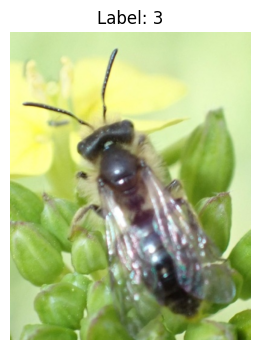

Image size: (400, 512)


In [3]:
# Display one image
DATA_DIR = "data"

img_path = os.path.join(DATA_DIR, X.iloc[0])
img = Image.open(img_path)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Label: {y.iloc[0]}")
plt.axis("off")
plt.show()
print(f"Image size: {img.size}")

### 1.4 Class distribution

One of the main challenges is the **heavily imbalanced class distribution**.  The most common species has ~700 training images while the rarest have fewer than 10. Because the evaluation metric is **macro F1**, every class counts equally even the rare ones.

In [4]:
counts = data_train.groupby('label').size().sort_values(ascending=False).reset_index()
counts.columns = ['label', 'count']

print(f"Most common class: {counts['count'].max()} images")
print(f"Rarest class:      {counts['count'].min()} images")
print(f"Ratio max/min:     {counts['count'].max() / counts['count'].min():.0f}x")

fig = px.bar(
    counts, x=counts.index, y='count', color='count',
    title='Class distribution in the training set (sorted by frequency)',
    labels={'x': 'Class rank', 'count': 'Number of images'},
    color_continuous_scale='plasma'
)
fig.show()

Most common class: 718 images
Rarest class:      4 images
Ratio max/min:     180x


## 2. Modelling Pipeline

### Architecture choice: EfficientNetV2-S

We chose **EfficientNetV2-S** as our backbone because:
- It achieves excellent accuracy/size trade-offs (important for the embedded deployment constraint)
- It generalises well when fine-tuned from ImageNet weights
- Its compound scaling makes it more efficient than EfficientNet-B* variants for similar accuracy

The custom classifier head is: `Dropout(p) → Linear(in_features → 50 classes)` using **dropout for regularisation** and outputting logits for all 50 species.


### 2.1 Core imports

In [5]:
import os
from PIL import Image
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
from torchvision.transforms import v2
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
from collections import defaultdict
import random
from tqdm import tqdm

### 2.2 Transforms

We use two separate transform pipelines:

| Pipeline | When used | Purpose |
|---|---|---|
| `base_transform` | Validation, test, original train images | Deterministic resize + ImageNet normalisation |
| `aug_transform`  | Augmented copies of under-represented classes | Random geometric & colour perturbations to increase diversity |

ImageNet normalisation statistics are used because our backbone was pre-trained on ImageNet.


In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Base transform: used for validation, test, and unaugmented training images
base_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Augmentation transform: applied to synthetic copies of rare-class images
# Augmentations are chosen to be realistic for field photography:
# rotation (camera angle), colour jitter (lighting conditions),
# flips (bee orientation), and Gaussian blur (depth-of-field variation).
aug_transform = v2.Compose([
    v2.RandomRotation(30),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

### 2.3 Custom Dataset with dynamic augmentation

`BeeDataset` handles two complementary strategies for class imbalance:

1. **Offline augmentation** — for each under-represented class, synthetic copies are generated  
   by applying `aug_transform` to existing images. The number of copies per class is controlled  
   by `augment_factors` (proportional to the inverse of class frequency).

2. **Per-class cap** (`max_per_class`) — prevents dominant classes from overwhelming the dataset  
   even after augmentation.

Images are **pre-loaded into RAM** (`image_cache=True`) for faster training.


In [7]:
class BeeDataset(Dataset):
    def __init__(self, paths, labels, augment_factors=None,
                 apply_augmentation=True, max_per_class=300, image_cache=True):
        self.original_labels    = labels
        self.augment_factors    = augment_factors or {}
        self.apply_augmentation = apply_augmentation
        self.max_per_class      = max_per_class
        self.image_cache        = image_cache

        # Pre-load all images into RAM to avoid disk I/O bottlenecks during training
        if image_cache:
            print("Pre-loading images into RAM...")
            self.images_cache = [
                Image.open(p).convert("RGB") for p in tqdm(paths, desc="Cache")
            ]
        else:
            self.paths = paths

        self.indices, self.is_augmented = self._generate_indices()
        print(f"Dataset: {len(paths)} original images → {len(self.indices)} total samples (with augmentation)")

    def _generate_indices(self):
        """Build the flat index list that maps dataset positions to original images.
        
        Each original image may appear multiple times (once per augmentation factor).
        The `is_augmented` flag indicates whether aug_transform should be applied.
        """
        indices      = []
        is_augmented = []

        if self.apply_augmentation and self.augment_factors:
            for i, label in enumerate(self.original_labels):
                factor = self.augment_factors.get(label, 1)
                for k in range(factor):
                    indices.append(i)
                    is_augmented.append(k > 0)  # first copy is original, rest are augmented
        else:
            indices      = list(range(len(self.original_labels)))
            is_augmented = [False] * len(indices)
            return indices, is_augmented

        # Cap the number of samples per class to avoid over-representation of large classes
        if self.apply_augmentation and self.max_per_class is not None:
            class_positions = defaultdict(list)
            for pos, idx in enumerate(indices):
                class_positions[self.original_labels[idx]].append(pos)

            keep = []
            for positions in class_positions.values():
                keep.extend(
                    random.sample(positions, self.max_per_class)
                    if len(positions) > self.max_per_class
                    else positions
                )
            keep.sort()
            indices      = [indices[p]      for p in keep]
            is_augmented = [is_augmented[p] for p in keep]

        # Shuffle to avoid ordered class batches
        combined = list(zip(indices, is_augmented))
        random.shuffle(combined)
        indices, is_augmented = zip(*combined) if combined else ([], [])
        return list(indices), list(is_augmented)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        original_idx = self.indices[idx]

        if self.image_cache:
            img = self.images_cache[original_idx].copy()
        else:
            img = Image.open(self.paths[original_idx]).convert("RGB")

        label     = self.original_labels[original_idx]
        transform = aug_transform if self.is_augmented[idx] else base_transform
        img       = transform(img)

        return img, torch.tensor(label, dtype=torch.long)

### 2.4 Evaluation metrics

In [9]:
# Macro F1 is the competition metric, it penalises poor performance on rare classes
def f1_score_batch(preds, labels):
    return f1_score(
        labels.numpy(), torch.argmax(preds, dim=1).numpy(),
        average='macro', zero_division=0
    )

def precision_score_batch(preds, labels):
    return precision_score(
        labels.numpy(), torch.argmax(preds, dim=1).numpy(),
        average='macro', zero_division=0
    )

def recall_score_batch(preds, labels):
    return recall_score(
        labels.numpy(), torch.argmax(preds, dim=1).numpy(),
        average='macro', zero_division=0
    )

### 2.5 Train / Validation split

We use a **stratified 80/20 split** to ensure each species is proportionally represented in both the training and validation sets.


In [10]:
from sklearn.model_selection import train_test_split

DATA_DIR   = "data"
data_train = pd.read_csv('data/train.csv')
X          = data_train['id']
y          = data_train['label']
full_paths  = [os.path.join(DATA_DIR, p) for p in X]
labels      = y.values
num_classes = len(np.unique(labels))

# Stratified split: preserves class distribution in both splits
train_indices, val_indices = train_test_split(
    range(len(full_paths)), test_size=0.2, random_state=42, stratify=labels
)

train_paths  = [full_paths[i] for i in train_indices]
train_labels = [labels[i]    for i in train_indices]
val_paths    = [full_paths[i] for i in val_indices]
val_labels   = [labels[i]    for i in val_indices]

print(f"Training samples:   {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")

Training samples:   6399
Validation samples: 1600


## 3. Baseline Training (before hyperparameter optimisation)

Before running Optuna, we trained a baseline model with reasonable hand-picked hyperparametersto establish a reference point and validate the pipeline.

### WeightedRandomSampler

Even after augmentation, per-batch class balance is not guaranteed. We use `WeightedRandomSampler` to **oversample rare classes at batch-creation time**, assigning each sample a weight inversely proportional to its class frequency. This means rare classes are drawn more often during training, directly addressing macro F1 optimisation.


In [11]:
# Compute augmentation factors (how many copies to generate per class)
class_counts = np.bincount(train_labels)

# max_count = highest class count / divisor  -->  target count for all classes
max_count       = class_counts.max() / 10
augment_factors = {
    c: int(np.ceil(max_count / cnt))
    for c, cnt in enumerate(class_counts) if cnt > 0
}

print("Top augmentation factors (rarest classes get the most copies):")
for c, f in sorted(augment_factors.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  Class {c:2d} : {class_counts[c]:4d} images x {f:3d} → {class_counts[c]*f:5d} total")

# ── Build datasets ──────────────────────────────────────────────────────────
train_dataset = BeeDataset(train_paths, train_labels,
                           augment_factors=augment_factors,
                           apply_augmentation=True, max_per_class=300)
val_dataset   = BeeDataset(val_paths, val_labels,
                           apply_augmentation=False, max_per_class=1000)

# ── WeightedRandomSampler: upsamples rare classes at batch level ────────────
train_labels_ext = [train_labels[i] for i in train_dataset.indices]
train_class_cnts = np.bincount(train_labels_ext, minlength=num_classes)
class_weights    = 1.0 / (train_class_cnts + 1e-6)  # inverse frequency
sample_weights   = [class_weights[l] for l in train_labels_ext]
sampler          = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

print(f"\nClass distribution after augmentation (min / max): "
      f"{train_class_cnts.min()} / {train_class_cnts.max()}")

Top augmentation factors (rarest classes get the most copies):
  Class  1 :    3 images ×  20 →    60 total
  Class 30 :    3 images ×  20 →    60 total
  Class  0 :    4 images ×  15 →    60 total
  Class 34 :    4 images ×  15 →    60 total
  Class 10 :    5 images ×  12 →    60 total
  Class 20 :    5 images ×  12 →    60 total
  Class 26 :    5 images ×  12 →    60 total
  Class 27 :    5 images ×  12 →    60 total
  Class 33 :    5 images ×  12 →    60 total
  Class 48 :    5 images ×  12 →    60 total
Pre-loading images into RAM...


Cache: 100%|██████████| 6399/6399 [00:38<00:00, 168.03it/s]


Dataset: 6399 original images → 7970 total samples (with augmentation)
Pre-loading images into RAM...


Cache: 100%|██████████| 1600/1600 [00:08<00:00, 188.61it/s]

Dataset: 1600 original images → 1600 total samples (with augmentation)

Class distribution after augmentation (min / max): 58 / 574


In [12]:
# Model: EfficientNetV2-S fine-tuned from ImageNet weights
device     = torch.device("mps")  # Apple Silicon GPU; use "cuda" or "cpu" as appropriate
base_model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)

# Replace the default classifier with one targeting our 50 species
base_model.classifier[1] = nn.Linear(base_model.classifier[1].in_features, num_classes)
base_model = base_model.to(device)

# CrossEntropyLoss with label smoothing reduces overconfidence on rare classes
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(base_model.parameters(), lr=1e-4)

print(f"Model ready - {num_classes} output classes")

Model ready — 50 output classes


In [ ]:
# Training loop 
num_epochs  = 20
scheduler   = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
best_val_f1 = 0.0

for epoch in range(num_epochs):

    base_model.train()
    running_loss        = 0.0
    all_preds, all_lbls = [], []

    for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = base_model(imgs)
        loss    = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        all_preds.append(outputs.detach().cpu())
        all_lbls.append(lbls.cpu())

    all_preds = torch.cat(all_preds)
    all_lbls  = torch.cat(all_lbls)
    print(f"\nEpoch {epoch+1} | Loss {running_loss/len(train_loader):.4f} | "
          f"F1 {f1_score_batch(all_preds, all_lbls):.4f} | "
          f"P {precision_score_batch(all_preds, all_lbls):.4f} | "
          f"R {recall_score_batch(all_preds, all_lbls):.4f}")

    # Validation phase 
    base_model.eval()
    val_preds, val_lbls = [], []

    with torch.no_grad():
        for imgs, lbls in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            imgs, lbls = imgs.to(device), lbls.to(device)
            val_preds.append(base_model(imgs).cpu())
            val_lbls.append(lbls.cpu())

    val_preds = torch.cat(val_preds)
    val_lbls  = torch.cat(val_lbls)
    val_f1    = f1_score_batch(val_preds, val_lbls)

    print(f"Val | F1 {val_f1:.4f} | "
          f"P {precision_score_batch(val_preds, val_lbls):.4f} | "
          f"R {recall_score_batch(val_preds, val_lbls):.4f}\n")

    # Save the best checkpoint based on validation F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(base_model.state_dict(), "best_model_baseline.pth")
        print(f"  ✓ New best model saved (Val F1 = {best_val_f1:.4f})\n")

    scheduler.step()

## 4. Hyperparameter Optimisation with Optuna

To squeeze out the best macro F1, we ran a Bayesian hyperparameter search with **Optuna** over the following parameters:

| Parameter | Range | Role |
|---|---|---|
| `divisor` | 5 → 50 | Controls augmentation intensity: `max_count = max_class / divisor` |
| `max_per_class` | 50 → 500 | Cap on augmented samples per class (step 50) |
| `lr` | 1e-5 → 1e-3 | Learning rate (log scale) |
| `dropout` | 0.2 → 0.6 | Classifier dropout for regularisation |
| `num_epochs` | 10 → 30 | Maximum training epochs per trial |

Each trial trains a fresh model and returns its best validation F1 as the objective to maximise.


In [13]:
import optuna

# Load the Optuna study from the SQLite database (generated during the search)
study = optuna.load_study(
    study_name='bee_classification',
    storage='sqlite:///optuna_study.db'
)

print(f"Best Val F1 : {study.best_value:.4f}")
print(f"Best trial  : #{study.best_trial.number}")
print("\nBest hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k:20s} : {v}")

/opt/anaconda3/envs/deep/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



Best Val F1 : 0.7761
Best trial  : #2

Best hyperparameters:
  divisor              : 5
  max_per_class        : 500
  lr                   : 0.000462258900102083
  dropout              : 0.28493564427131046
  num_epochs           : 13


## 5. Inference on the Test Set

We reload the best checkpoint found with Optuna and run inference on the held-out test set. The test DataLoader uses `shuffle=False` to guarantee that predictions are written in the same order as the test CSV.


In [ ]:
test_data  = pd.read_csv('data/test.csv')
TEST_DIR   = os.path.join(DATA_DIR, "test")

# Build test image paths (ids are filenames without extension)
test_paths = [os.path.join(TEST_DIR, str(p) + ".jpg") for p in test_data['id']]

# Test dataset (no augmentation, no shuffle)
test_dataset = BeeDataset(
    test_paths, [0] * len(test_paths),
    augment_factors={}, apply_augmentation=False,
    max_per_class=100000, image_cache=False
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load best checkpoint
best_model = models.efficientnet_v2_s(weights=None)
in_features = best_model.classifier[1].in_features
best_model.classifier = nn.Sequential(
    nn.Dropout(p=study.best_params['dropout']),
    nn.Linear(in_features, num_classes)
)
best_model.load_state_dict(torch.load("best_model_optuna.pth", map_location=device))
best_model = best_model.to(device)
best_model.eval()

# Inference loop
predictions = []
with torch.no_grad():
    for imgs, _ in tqdm(test_loader, desc="Inference"):
        imgs    = imgs.to(device)
        outputs = best_model(imgs)
        preds   = torch.argmax(outputs, dim=1).cpu().numpy()
        predictions.extend(preds)

# Save submission
submission = pd.DataFrame({'id': test_data['id'], 'label': predictions})
submission.to_csv('submission.csv', index=False)
print(f"Submission saved — {len(predictions)} predictions")
submission.head()

## 6. Post-hoc Analysis

### 6.1 Detailed validation report

We inspect per-class precision, recall and F1 to understand where the model struggles (typically the smallest classes) and where it performs well.


In [15]:
from sklearn.metrics import classification_report

# Reload best model for validation analysis
eval_model = models.efficientnet_v2_s(weights=None)
in_features = eval_model.classifier[1].in_features
eval_model.classifier = nn.Sequential(
    nn.Dropout(p=study.best_params['dropout']),
    nn.Linear(in_features, num_classes)
)
eval_model.load_state_dict(torch.load("best_model_optuna.pth", map_location=device))
eval_model = eval_model.to(device)
eval_model.eval()

all_preds_val  = []
all_labels_val = []

with torch.no_grad():
    for imgs, lbls in tqdm(val_loader, desc="Validation inference"):
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs    = eval_model(imgs)
        preds      = torch.argmax(outputs, dim=1)
        all_preds_val.extend(preds.cpu().numpy())
        all_labels_val.extend(lbls.cpu().numpy())

print(classification_report(all_labels_val, all_preds_val, zero_division=0))

Validation inference: 100%|██████████| 50/50 [00:12<00:00,  3.91it/s]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       0.77      0.82      0.79       100
           3       0.75      1.00      0.86         3
           4       0.50      0.33      0.40         3
           5       0.92      0.81      0.86        86
           6       1.00      0.25      0.40         4
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       0.60      0.60      0.60         5
          10       1.00      1.00      1.00         1
          11       1.00      0.71      0.83         7
          12       0.82      0.84      0.83        79
          13       1.00      0.33      0.50         3
          14       0.83      0.90      0.86        21
          15       1.00      1.00      1.00         6
          16       0.50      0.25      0.33         4
          17       0.88    

### 6.2 Augmented class distribution (before WeightedRandomSampler)

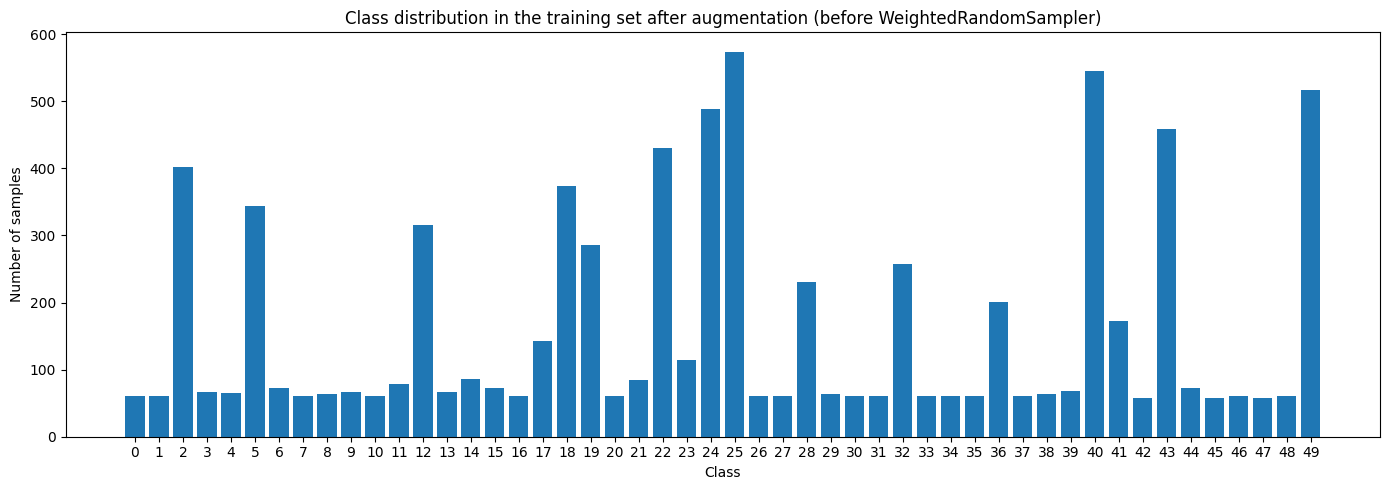

Min samples per class: 58
Max samples per class: 574


In [16]:
# Visualise the class distribution in the training set after augmentation
train_labels_ext = [train_labels[i] for i in train_dataset.indices]
train_class_cnts = np.bincount(train_labels_ext, minlength=num_classes)
classes          = np.arange(num_classes)

plt.figure(figsize=(14, 5))
plt.bar(classes, train_class_cnts)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Class distribution in the training set after augmentation (before WeightedRandomSampler)")
plt.xticks(classes)
plt.tight_layout()
plt.show()

print(f"Min samples per class: {train_class_cnts.min()}")
print(f"Max samples per class: {train_class_cnts.max()}")

## 7. Conclusion

### What we did

This project tackled fine-grained species classification of **Andrena bees** under a severely imbalanced class distribution (700 images for the most common species vs. fewer than 10 for the rarest).  
The evaluation metric **macro F1** means every class matters equally, making imbalance handling critical.

Our pipeline combined three complementary strategies:

1. **Dynamic offline augmentation**: under-represented classes received synthetic copies generated with realistic field-photography perturbations (rotation, colour jitter, blur, flips).

2. **WeightedRandomSampler**: rare classes are over-sampled at batch-creation time, independently of the static augmentation, ensuring balanced mini-batches throughout training.

3. **Bayesian hyperparameter optimisation (Optuna)**: we searched over augmentation intensity, per-class caps, learning rate, dropout, and number of epochs to find the configuration that maximises validation F1, rather than hand-tuning each value.

Our backbone, **EfficientNetV2-S** pre-trained on ImageNet, provided a strong visual feature extractor that was fine-tuned end-to-end with a dropout + linear classifier head.

**CrossEntropyLoss with label smoothing (0.1)** helped prevent overconfidence on the few high-support classes.


### Results

| Metric | Score |
|---|---|
| Train F1 (macro) | **0.99** |
| Validation F1 (macro) | **0.7761** |
| **Private test F1 (macro)** | **0.766** |
| **Leaderboard rank** | **1st place** |

**Per-class analysis:**
- High-support classes (>80 images): consistent F1 > 0.77, reaching up to 0.89 for some species
- Rare classes (<5 images): some F1 = 0.00, unavoidable without more data
- The train/val F1 gap (~0.21) is kept in check by dropout and data augmentation